In [1]:
from funcs import *
import pandas as pd
import cvxpy as cp
import numpy as np
from numpy.linalg import pinv
from scipy.sparse import lil_matrix
from scipy.stats import binom
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from sklearn.linear_model import LogisticRegression
import tqdm
from tqdm import trange

# Bootstrapping and the Quantile Universal Threshold

In this notebook, we will be performing a variety of statistical methods to ensure that there is a signal to be captured within the movement data alongside generating distributions of our $\lambda$ values using bootstrapping techniques. The Quantile Universal Threshold (QUT) will be calculated using a combination of the two techniques and will be described in further detail within the notebook.

For consistency and interpretability, all ball movements will directed towards one basket, which will be on the right side of all future visualizations.

In [2]:
df = pd.read_csv("Data/bootstrapped_analysis_ready.csv")

mask = df["period"] > 2
df.loc[mask, "x_bin"] = 20 - 1 - df.loc[mask, "x_bin"]
df.loc[mask, "y_bin"] = 10 - 1 - df.loc[mask, "y_bin"]

df['x_bin'] = np.clip(df['x_bin'], 0, 20 - 1)
df['y_bin'] = np.clip(df['y_bin'], 0, 10 - 1)

df

,Unnamed: 0,period,time,x,y,z,possession_start,possession_end,possession_number,scored,x_bin,y_bin
0,5478,1,519.52,88.59020,23.33939,7.01082,525.0,517.0,100000,1,18,4
1,5393,1,522.92,60.33963,47.03315,5.05533,525.0,517.0,100000,1,12,9
2,5156,1,524.40,56.15521,46.22760,4.01930,525.0,517.0,100000,1,11,9
3,5465,1,520.04,86.94073,22.81185,7.60527,525.0,517.0,100000,1,18,4
4,5522,1,517.76,91.09229,30.78871,4.90019,525.0,517.0,100000,1,19,6
...,...,...,...,...,...,...,...,...,...,...,...,...
99995,25788,1,32.22,38.09371,25.18775,3.11391,33.0,15.0,100999,1,8,5
99996,26215,1,16.38,89.32768,26.19356,10.86343,33.0,15.0,100999,1,19,5
99997,25874,1,30.02,51.96869,25.74845,1.19712,33.0,15.0,100999,1,11,5
99998,25775,1,32.74,35.54421,26.63212,2.20840,33.0,15.0,100999,1,7,5


## First Bootstrap and QUT Calculation

The goal of the QUT is to generate values of our $\lambda$ that drive the response of our model to zero, essentially generating a constant signal across our generated threat map. Our alternate hypothesis is that there is a signal to be captured, so we must provide sufficient evidence that the signal in non-noisy or random data requires a sufficiently weaker $\lambda$ value to drive our threat map values to a constant signal. Because our original data set is small, we use bootstrapping to generate a distribution of $\lambda$ values under the null and the actual data.

The first bootstrapped data set was created in the `testing.ipynb` file where we randomly selected $1000$ possessions and $100$ positions from each posssession, both done with replacement. With this data set, we perform our QUT calculation by simulating a null response by applying logistic regression to our `X` matrix (movement data) with the `y` target vector (scored/no score). The model collapses our input matrix into a single vector to get a a single coefficient, `B0`, which will act as a baseline for our null response that assumes there is no signal to be capture within our data. We then use `B0` to generate probalities (`p`) of scoring under the null hypothesis.

With `p`, we then solve a linear optimization problem to generate the max $\lambda$ values to drive the response to zero. The formulation of the problem is as follows:


\begin{aligned}
\min_{w \in \mathbb{R}^m} \quad & \| w \|_{\infty} \\
\text{s.t.} \quad & D^{\mathsf{T}} w = \nabla_h
\end{aligned}

where $w$ is our variable to optimize, $||w||_\infty$ is the infinity normal, $D^T$ is our total variation matrix that represents the difference between neighbouring edges, and $\Delta_h$ is our gradient of the predicted `p` subtracted from our actual `y` values.

We run this simulation $1000$ times in the cells below.

In [3]:
X, y, D_TV = grid(df)

lambda_qut_val, lambda_max, lambdas_null = lambda_qut(X, y, D_TV, MC=1000)

Simulating null responses...
Accepted 100 / 1000 simulations
Accepted 200 / 1000 simulations
Accepted 300 / 1000 simulations
Accepted 400 / 1000 simulations
Accepted 500 / 1000 simulations
Accepted 600 / 1000 simulations
Accepted 700 / 1000 simulations
Accepted 800 / 1000 simulations
Accepted 900 / 1000 simulations
Accepted 1000 / 1000 simulations
λ_qut (95th percentile null): 15.2325
λ_max (data): 32.4136


## Results

After running the simulations, we can see that there is a statistically significant difference between $\lambda_{max}$ and the 95th percentile of our null, or $\lambda_{QUT}$. Before we make any claims, we will enhance this and perform the same QUT methods on multiple bootstrapped datasets to get a distribution of $\lambda_{max}$ and $\lambda_{QUT}$ so we can compare them using a p-value for statistical significance and hypothesis testing.

For a sanity check, we also visualized a threat map using our $\lambda_{QUT}$ value. This will give a visual confirmation if the underlying signal in the data is able to overcome the strong penalty applied to the null that drives it to zero. Based on the results, there is still a signal being captured despite the strong total variation penalty applied to the data. 

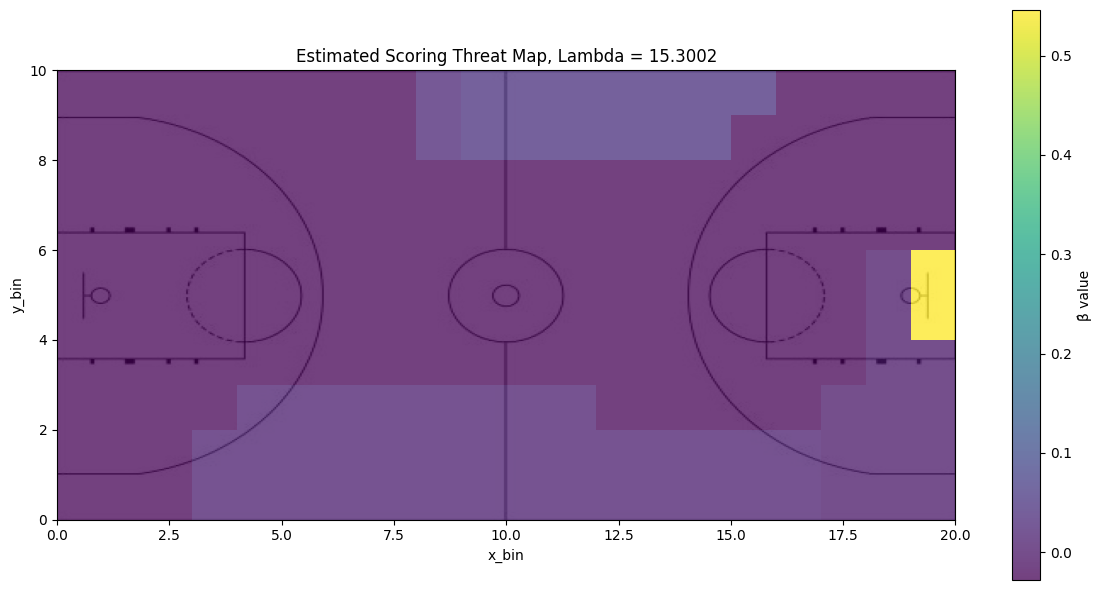

array([[-0.02800431, -0.02800431, -0.02800431, -0.02800431, -0.02800431,
        -0.0280043 , -0.0280043 , -0.0280043 , -0.0280043 , -0.0280043 ],
       [-0.02800431, -0.02800431, -0.02800431, -0.02800431, -0.02800431,
        -0.0280043 , -0.0280043 , -0.0280043 , -0.0280043 , -0.0280043 ],
       [-0.02800431, -0.02800431, -0.02800431, -0.02800431, -0.02800431,
        -0.02800431, -0.0280043 , -0.0280043 , -0.0280043 , -0.0280043 ],
       [ 0.01403951,  0.01403951, -0.02800431, -0.02800431, -0.02800431,
        -0.02800431, -0.0280043 , -0.0280043 , -0.0280043 , -0.0280043 ],
       [ 0.01403951,  0.01403951,  0.01403951, -0.02800431, -0.02800431,
        -0.02800431, -0.0280043 , -0.0280043 , -0.0280043 , -0.0280043 ],
       [ 0.01403951,  0.01403951,  0.01403951, -0.02800431, -0.02800431,
        -0.02800431, -0.0280043 , -0.0280043 , -0.0280043 , -0.0280043 ],
       [ 0.01403951,  0.01403951,  0.01403951, -0.02800431, -0.02800431,
        -0.02800431, -0.0280043 , -0.0280043 

In [4]:
tv_logistic_regression_heatmap(df, 15.3002, plot=True)

In [5]:
# Flipping coordinates for unidirectional attack towards the right side basket

df_original = pd.read_csv("Data/analysis_ready.csv")

mask = df_original["period"] > 2
df_original.loc[mask, "x_bin"] = 20 - 1 - df_original.loc[mask, "x_bin"]
df_original.loc[mask, "y_bin"] = 10 - 1 - df_original.loc[mask, "y_bin"]

df_original['x_bin'] = np.clip(df_original['x_bin'], 0, 20 - 1)
df_original['y_bin'] = np.clip(df_original['y_bin'], 0, 10 - 1)

X, y, D_TV = grid(df_original)

In [6]:
# Function to compute lambda_max for each bootstrapped dataset

def compute_lambda_max_from_bootstraps(boot_datasets, D_TV, solve_lambda_func, project_grad_h=True):
    lambda_max_list = []

    for df_b in tqdm.tqdm(boot_datasets, desc="Computing λ_max for bootstraps"):
        # Build X, y from each bootstrapped dataset
        possessions = df_b['possession_number'].unique()
        grid_width, grid_height = 20, 10
        num_bins = grid_width * grid_height

        X = lil_matrix((len(possessions), num_bins), dtype=np.float32)
        y = np.array([group['scored'].iloc[0] for _, group in df_b.groupby('possession_number')], dtype=np.int8)
        possession_to_index = {p: i for i, p in enumerate(possessions)}
        bin_to_index = {(x, y): x * grid_height + y for x in range(grid_width) for y in range(grid_height)}

        for pid, group in df_b.groupby('possession_number'):
            i = possession_to_index[pid]
            visited_bins = set(zip(group['x_bin'], group['y_bin']))
            for xb, yb in visited_bins:
                if (xb, yb) in bin_to_index:
                    X[i, bin_to_index[(xb, yb)]] = 1

        try:
            _, lambda_max_b = solve_lambda_func(y, X, D_TV, project_grad_h=project_grad_h)
            if np.isfinite(lambda_max_b):
                lambda_max_list.append(lambda_max_b)
        except:
            continue

    return np.array(lambda_max_list)

In [7]:
# helper function to visualize distributions of observed lambda_max and the null

def summarize_lambda_max_analysis(
    lambda_max_obs,
    lambda_max_null,
    lambda_max_bootstrap,
    plot=True
):
    """
    Summarize the λ_max statistical test including CI, p-value, and QUT.

    Parameters:
    - lambda_max_obs (float): Observed λ_max from real or bootstrapped data
    - lambda_max_null (array-like): λ_max values simulated under the null
    - lambda_max_bootstrap (array-like): λ_max values from bootstrapped real data
    - plot (bool): Whether to plot the distributions

    Returns:
    - dict with keys: 'lambda_qut', 'lambda_max_obs', 'ci', 'p_value'
    """

    lambda_max_null = np.asarray(lambda_max_null)
    lambda_max_bootstrap = np.asarray(lambda_max_bootstrap)

    lambda_qut = np.percentile(lambda_max_null, 95)
    ci_lower, ci_upper = np.quantile(lambda_max_bootstrap, [0.025, 0.975])
    p_val = np.mean(lambda_max_null >= lambda_max_obs)

    print(f"λ_qut (95th percentile null): {lambda_qut:.4f}")
    print(f"λ_max (observed): {lambda_max_obs:.4f}")
    print(f"95% CI for λ_max (bootstrap): [{ci_lower:.4f}, {ci_upper:.4f}]")
    print(f"Empirical p-value (λ_max > λ_qut): {p_val:.4f}")

    if plot:
        import matplotlib.pyplot as plt
        plt.figure(figsize=(10, 6))
        plt.hist(lambda_max_null, bins=50, alpha=0.5, label="λ_max (null)", color="gray")
        plt.hist(lambda_max_bootstrap, bins=50, alpha=0.5, label="λ_max (bootstrap)", color="skyblue")
        plt.axvline(lambda_qut, color="black", linestyle="--", label="λ_qut (95%)")
        plt.axvline(lambda_max_obs, color="red", linestyle="--", label="λ_max (observed)")
        plt.xlabel("λ_max")
        plt.ylabel("Frequency")
        plt.title("λ_max: Bootstrap vs. Null Distribution")
        plt.legend()
        plt.tight_layout()
        plt.show()

    return {
        "lambda_qut": lambda_qut,
        "lambda_max_obs": lambda_max_obs,
        "ci": (ci_lower, ci_upper),
        "p_value": p_val
    }

## Bootstrapping Multiple Datasets for Comparison

For hypothesis testing, we need to create a distribution of the null and our actual $\lambda_{max}$. To do this, we follow the exact same steps covered above but we extend it to multiple bootstrapped datasets. The method has also been extended for customization, allowing you to input other datasets of that follow a similar structure and generate any amount of bootstraps with the option to fine tune how much sampling you would like to do. Reproducibilty is also built in.

## Results

Using the same parameters as the first iteration ($1000$ possessions and $100$ samples), alongside sample filtering, we construct a distribution of $\lambda_{max}$ alongside a 95% confidence interval and an empirical p-value. With a reported p-value of 0, we can confidently reject the null hypothesis and claim that there is an underlying signal within the data. With this, we can now start to create pointwise confidence intervals and other measurements using a fixed $\lambda$ value of our choice.

Computing λ_max for bootstraps: 100%|██████████| 100/100 [00:26<00:00,  3.74it/s]


λ_qut (95th percentile null): 15.2325
λ_max (observed): 32.4136
95% CI for λ_max (bootstrap): [29.7348, 41.3879]
Empirical p-value (λ_max > λ_qut): 0.0000


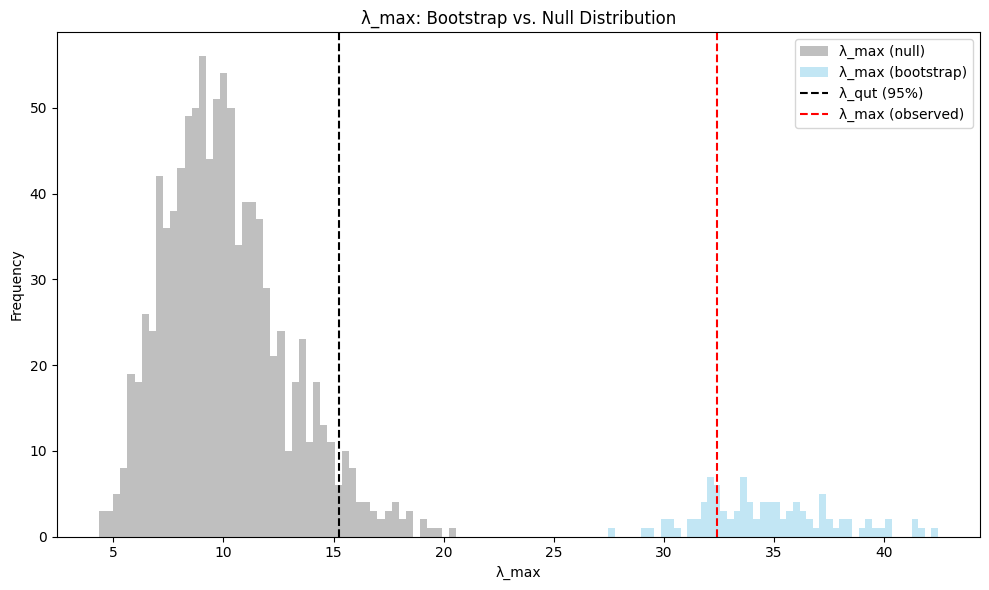

In [8]:
# Step 1: Generate bootstrapped datasets
boot_datasets = generate_bootstrapped_datasets(
    df_original,
    n_bootstraps=100,
    n_possessions_per_bootstrap=1000,
    samples_per_possession=100,
    min_samples_required=100,
    seed=42
)

# Step 2: Compute λ_max per bootstrap
lambda_max_bootstrap = compute_lambda_max_from_bootstraps(
    boot_datasets,
    D_TV,
    solve_lambda_func=solve_infinity_norm,
    project_grad_h=True
)

# Step 3: Compare to null distribution
summary = summarize_lambda_max_analysis(
    lambda_max_obs=lambda_max,
    lambda_max_null=lambdas_null,
    lambda_max_bootstrap=lambda_max_bootstrap,
    plot=True
)

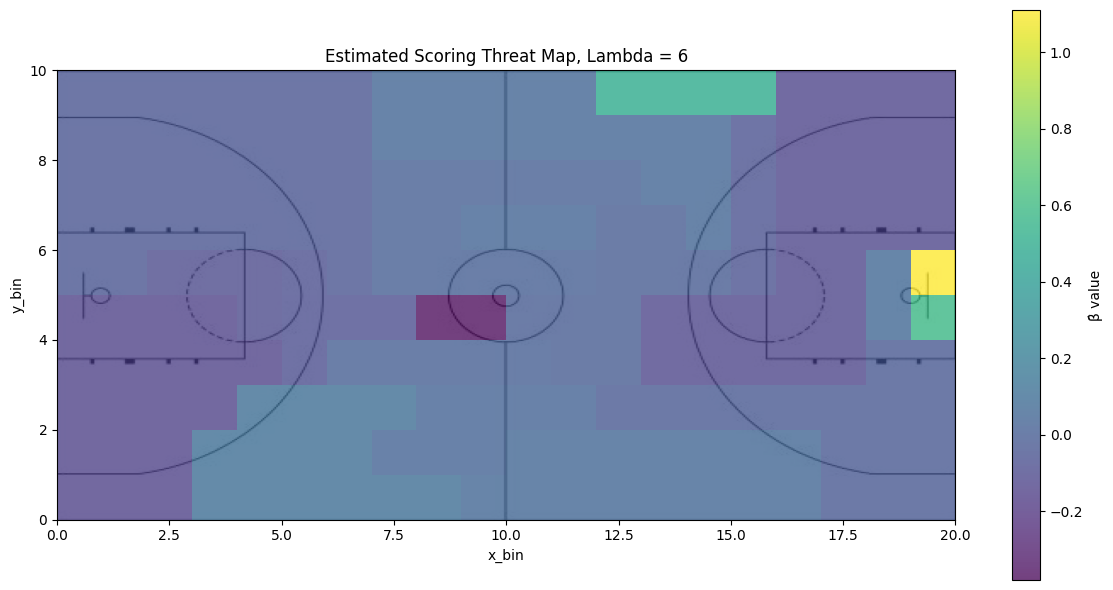

array([[-0.13795583, -0.13795583, -0.13795583, -0.13795583, -0.13795583,
        -0.043219  , -0.043219  , -0.043219  , -0.043219  , -0.043219  ],
       [-0.13795583, -0.13795583, -0.13795583, -0.13795583, -0.13795583,
        -0.043219  , -0.043219  , -0.043219  , -0.043219  , -0.043219  ],
       [-0.13795583, -0.13795583, -0.13795583, -0.13795583, -0.13795583,
        -0.09539297, -0.043219  , -0.043219  , -0.043219  , -0.043219  ],
       [ 0.10760688,  0.10760688, -0.13795583, -0.13795583, -0.13795583,
        -0.09539297, -0.04321901, -0.043219  , -0.043219  , -0.043219  ],
       [ 0.10760688,  0.10760688,  0.10760688, -0.13795583, -0.09539297,
        -0.09539297, -0.04321901, -0.04321901, -0.043219  , -0.043219  ],
       [ 0.10760688,  0.10760688,  0.10760688, -0.08089906, -0.08089906,
        -0.07260018, -0.043219  , -0.04321901, -0.043219  , -0.043219  ],
       [ 0.10760688,  0.10760688,  0.10760688,  0.00879384, -0.08089906,
        -0.043219  , -0.043219  , -0.04321901

In [9]:
tv_logistic_regression_heatmap(boot_datasets[0], 6, plot = True)

In [10]:
# function for pointwise measurements (CI)

def bootstrap_percentile_maps_fixed_lambda(
    boot_datasets,             # list of bootstrapped DataFrames
    lambda_tv,                 # fixed λ (e.g., lambda_qut or lambda_max)
    grid_width, grid_height,   # grid shape
    court_image_path="court.jpg",
    alpha=0.05,
    show_progress=True
):
    """
    Calls tv_logistic_regression_heatmap on each bootstrap with fixed λ.
    Collects *logit* maps and returns percentile summaries on the logit scale.
    """
    B = len(boot_datasets)
    maps = None
    rng = np.random.default_rng(0)

    it = trange(B, desc=f"Bootstraps @ fixed λ={lambda_tv:.4g}") if show_progress else range(B)
    for b in it:
        df_b = boot_datasets[b]

        out = tv_logistic_regression_heatmap(
            df_b,
            lambda_tv=lambda_tv,
            grid_width=grid_width,
            grid_height=grid_height,
            court_image_path=court_image_path,
            plot=False  # no plotting in loop
        )

        # Your function may return either logits or (logits, prob_map).
        beta_logit = out[0] if isinstance(out, tuple) else out  # ensure we keep logits
        if maps is None:
            maps = np.empty((B, grid_width, grid_height), dtype=np.float32)
        maps[b] = beta_logit

    # Pointwise percentile summaries on the logit scale
    q_lo, q_hi = alpha/2, 1 - alpha/2
    logit_lo  = np.quantile(maps, q_lo, axis=0)
    logit_med = np.median(maps, axis=0)
    logit_hi  = np.quantile(maps, q_hi, axis=0)

    return logit_med, logit_lo, logit_hi, maps

def plot_three_maps(logit_lo, logit_med, logit_hi, court_image_path, vlim=None):
    # Suggest a symmetric vlim if not provided, using robust percentiles
    if vlim is None:
        v = np.percentile(np.abs(np.stack([logit_lo, logit_med, logit_hi])), 95)
        vlim = (-float(v), float(v))

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    img = mpimg.imread(court_image_path)

    for ax, data, title in zip(
        axes,
        [logit_lo, logit_med, logit_hi],
        ["Conservative (Lower, logit)", "Realistic (Median, logit)", "Optimistic (Upper, logit)"]
    ):
        ax.imshow(img, extent=[0, data.shape[0], 0, data.shape[1]], aspect='auto')
        im = ax.imshow(
            data.T, origin="lower",
            extent=[0, data.shape[0], 0, data.shape[1]],
            cmap="coolwarm", alpha=0.75, vmin=vlim[0], vmax=vlim[1]
        )
        ax.set_xlabel("x_bin"); ax.set_ylabel("y_bin"); ax.set_title(title)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Logit (β̂)")

    plt.tight_layout(); plt.show()

## Pointwise Measurements Using a Fixed $\lambda$

Using our previously created bootstrapped datsets, we can now do pointwise measurements for each sector of the court. We created three plots; a conservative measurement, realistic measurement and an optimistic measurement using the a 95% confidence interval, or an $\alpha$ of .05. This value can be adjusted for the user's needs. Alongside the aforementioned plots, we also constructed the mean value and standard deviation for each sector of the court.

Bootstraps @ fixed λ=6: 100%|██████████| 100/100 [01:30<00:00,  1.11it/s]


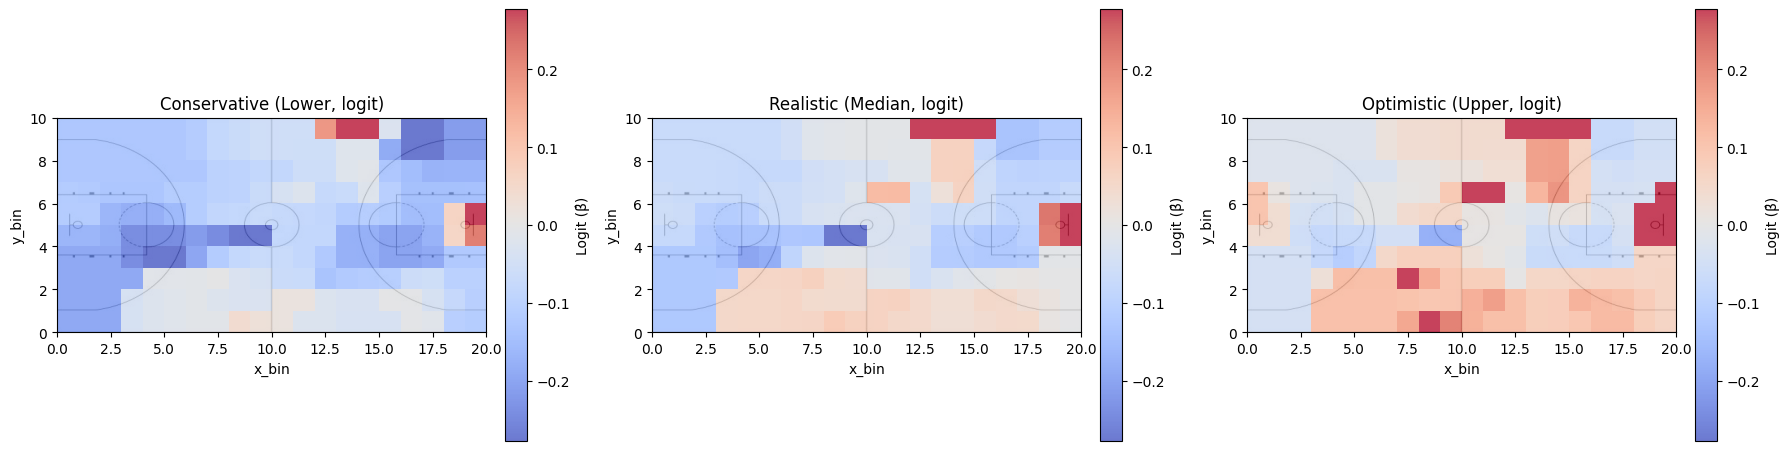

In [11]:
theta_hat, theta_lo, theta_hi, maps = bootstrap_percentile_maps_fixed_lambda(
    boot_datasets=boot_datasets,
    lambda_tv = 6,   #QUT or lambda_max
    grid_width=20, grid_height=10,
    court_image_path="court.jpg",
    alpha=0.05
)

# plot (optional)
plot_three_maps(theta_lo, theta_hat, theta_hi, "court.jpg")

In [12]:
# functions for pointwise measurements (mean, std)

def generate_beta_samples_from_bootstraps(boot_datasets, lambda_tv=1.0):
    beta_list = []

    for df_b in tqdm.tqdm(boot_datasets, desc="Solving TV-Logistic"):
        try:
            beta_b = solve_tv_logistic_regression(df_b, lambda_tv=lambda_tv)
            beta_list.append(beta_b)
        except RuntimeError as e:
            print("Skipped due to optimization failure:", e)
            continue

    return np.stack(beta_list)

def compute_beta_summary_stats(beta_samples):
    """
    Compute mean and std dev per cell from bootstrapped beta samples.
    
    Parameters:
        beta_samples (np.ndarray): shape (B, grid_width, grid_height)
        
    Returns:
        beta_mean, beta_std (both np.ndarray): shape (grid_width, grid_height)
    """
    beta_mean = np.mean(beta_samples, axis=0)
    beta_std = np.std(beta_samples, axis=0)
    return beta_mean, beta_std

def plot_beta_mean_std(beta_mean, beta_std, court_image_path=None):
    """
    Visualize mean and standard deviation of beta values across the court grid.
    """
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    titles = ["Mean of β (Bootstrapped)", "Standard Deviation of β"]
    matrices = [beta_mean, beta_std]
    cmaps = ["viridis", "plasma"]

    for ax, data, title, cmap in zip(axes, matrices, titles, cmaps):
        if court_image_path:
            from PIL import Image
            court_img = Image.open(court_image_path)
            ax.imshow(court_img, extent=[0, 20, 0, 10], aspect='auto')

        im = ax.imshow(data.T, origin="lower", extent=[0, 20, 0, 10],
                       cmap=cmap, alpha=0.7)
        ax.set_title(title)
        ax.set_xlabel("Court X")
        ax.set_ylabel("Court Y")
        plt.colorbar(im, ax=ax, shrink=0.8)

    plt.tight_layout()
    plt.show()


Solving TV-Logistic: 100%|██████████| 100/100 [01:32<00:00,  1.08it/s]


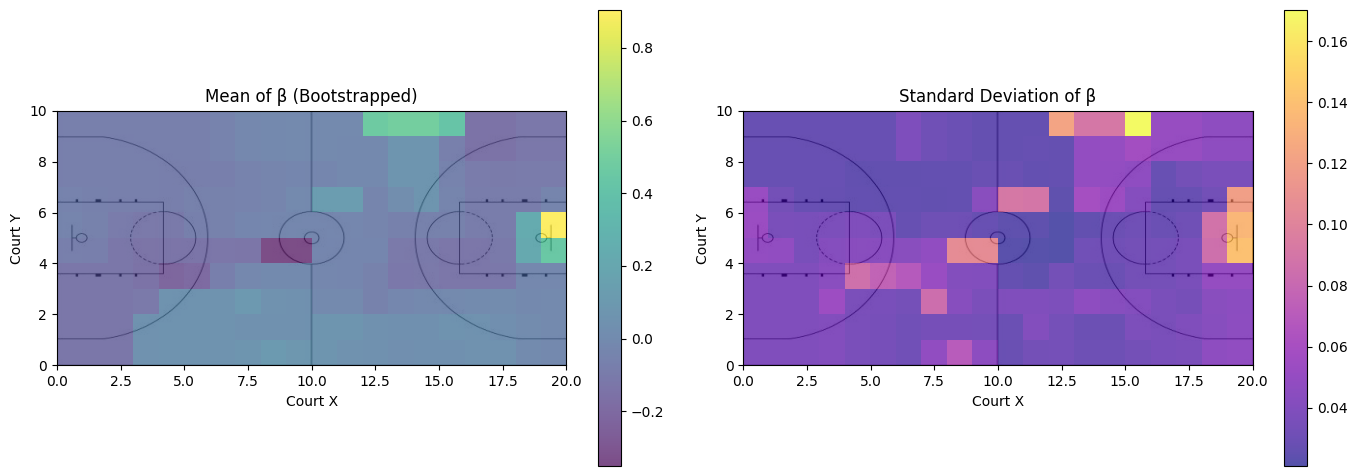

In [13]:
beta_samples = generate_beta_samples_from_bootstraps(boot_datasets, lambda_tv = 6)
beta_mean, beta_std = compute_beta_summary_stats(beta_samples)
plot_beta_mean_std(beta_mean, beta_std, court_image_path="court.jpg")

## Bootstrapping and QUT For Each Quarter

In [18]:
def analyze_tv_logistic_per_period(
    df_original,
    # Fixed λ used ONLY for pointwise maps & β summaries (decoupled from QUT/max)
    lambda_pointwise,                 
    n_bootstraps=100,
    n_possessions=500,
    samples_per_possession=100,
    min_samples_required=100,
    grid_width=20,
    grid_height=10,
    # null + plotting controls
    mc_null=500,                      # passed into your lambda_qut() to build null sims
    alpha=0.05,                       # used for pointwise percentile maps
    court_image_path="court.jpg",
    show_progress=True,
    plot_beta_summary=True,
    plot_pointwise_maps=True,
    plot_lambda_distributions=True,
    seed_base=42
):
    """
    For each period:
      • Builds bootstrap datasets
      • Computes β summaries (mean/std) at fixed λ = lambda_pointwise
      • Computes λ statistics via YOUR summarize_lambda_max_analysis():
          - λ_qut = 95th percentile of null
          - 95% CI for λ_max from data bootstrap
          - empirical p-value (per your helper’s definition)
      • Computes pointwise percentile maps (logit) at fixed λ = lambda_pointwise

    Notes:
      - The p-value returned by summarize_lambda_max_analysis is computed as
        mean(lambda_max_null >= lambda_max_obs) (see your helper).
    """
    rng = np.random.default_rng(seed_base)
    period_results = {}
    periods = sorted(df_original['period'].unique())

    for period in periods:
        print(f"\n=== Processing Period {period} @ fixed λ={lambda_pointwise:.4g} ===")

        df_period = df_original[df_original['period'] == period]

        # ---------- Step 0: Bootstrap datasets ----------
        boot_datasets = generate_bootstrapped_datasets(
            df_period,
            n_bootstraps=n_bootstraps,
            n_possessions_per_bootstrap=n_possessions,
            samples_per_possession=samples_per_possession,
            min_samples_required=min_samples_required,
            seed=seed_base + period
        )

        # ---------- Step 1: β summaries across bootstraps at fixed λ ----------
        beta_samples = generate_beta_samples_from_bootstraps(
            boot_datasets,
            lambda_tv=lambda_pointwise
        )
        beta_mean, beta_std = compute_beta_summary_stats(beta_samples)
        if plot_beta_summary:
            plot_beta_mean_std(beta_mean, beta_std, court_image_path=court_image_path)

        # ---------- Step 2: λ stats via YOUR helper ----------
        # Use a representative bootstrap to build X, y, D_TV
        df_boot = boot_datasets[0]
        X, y, D_TV = grid(df_boot)

        # Observed λ_max on this representative dataset
        _, lambda_max_obs = solve_infinity_norm(y, X, D_TV, project_grad_h=True)
        lambda_max_obs = float(lambda_max_obs)

        # Build null distribution of λ_max (and QUT) via your existing null routine.
        # Expected signature: lambda_qut(X, y, D_TV, mc_null) -> (lambda_qut_val, lambda_max_obs_again, lambdas_null)
        # We won't rely on lambda_qut_val from here; YOUR helper recomputes QUT from lambdas_null.
        _, _, lambdas_null = lambda_qut(X, y, D_TV, mc_null)

        # Bootstrap λ_max from data (data-world variability)
        lambda_max_bootstrap = compute_lambda_max_from_bootstraps(
            boot_datasets,
            D_TV,
            solve_lambda_func=solve_infinity_norm
        )

        # >>> Call YOUR summarizer (handles plotting & returns dict) <<<
        stats = summarize_lambda_max_analysis(
            lambda_max_obs=float(lambda_max_obs),
            lambda_max_null=np.asarray(lambdas_null, dtype=float),
            lambda_max_bootstrap=np.asarray(lambda_max_bootstrap, dtype=float),
            plot=plot_lambda_distributions
        )
        # stats keys: 'lambda_qut', 'lambda_max_obs', 'ci', 'p_value'

        # ---------- Step 3: Pointwise percentile maps (logit) at fixed λ ----------
        logit_med, logit_lo, logit_hi, maps_all = bootstrap_percentile_maps_fixed_lambda(
            boot_datasets=boot_datasets,
            lambda_tv=lambda_pointwise,
            grid_width=grid_width,
            grid_height=grid_height,
            court_image_path=court_image_path,
            alpha=alpha,
            show_progress=show_progress
        )
        if plot_pointwise_maps:
            print(f"Plotting pointwise percentile maps at fixed λ = {lambda_pointwise:.4g}")
            plot_three_maps(logit_lo, logit_med, logit_hi, court_image_path=court_image_path)

        # ---------- Step 4: Pack results ----------
        period_results[period] = {
            # β summaries at fixed λ
            "beta_samples": beta_samples,
            "beta_mean": beta_mean,
            "beta_std": beta_std,

            # λ statistics from YOUR helper
            "lambda_qut": stats["lambda_qut"],
            "lambda_max_obs": stats["lambda_max_obs"],
            "lambda_max_ci": stats["ci"],
            "p_value": stats["p_value"],

            # also return raw vectors in case you want further analysis
            "lambda_null": np.asarray(lambdas_null, dtype=float),
            "lambda_max_bootstrap": np.asarray(lambda_max_bootstrap, dtype=float),

            # Pointwise percentile maps at fixed λ
            "pointwise": {
                "lambda": float(lambda_pointwise),
                "alpha": float(alpha),
                "logit_lo": logit_lo,
                "logit_med": logit_med,
                "logit_hi": logit_hi,
                "maps": maps_all,   # shape: (B, grid_width, grid_height)
            }
        }

    return period_results



=== Processing Period 1 @ fixed λ=6 ===


Solving TV-Logistic: 100%|██████████| 100/100 [01:13<00:00,  1.36it/s]


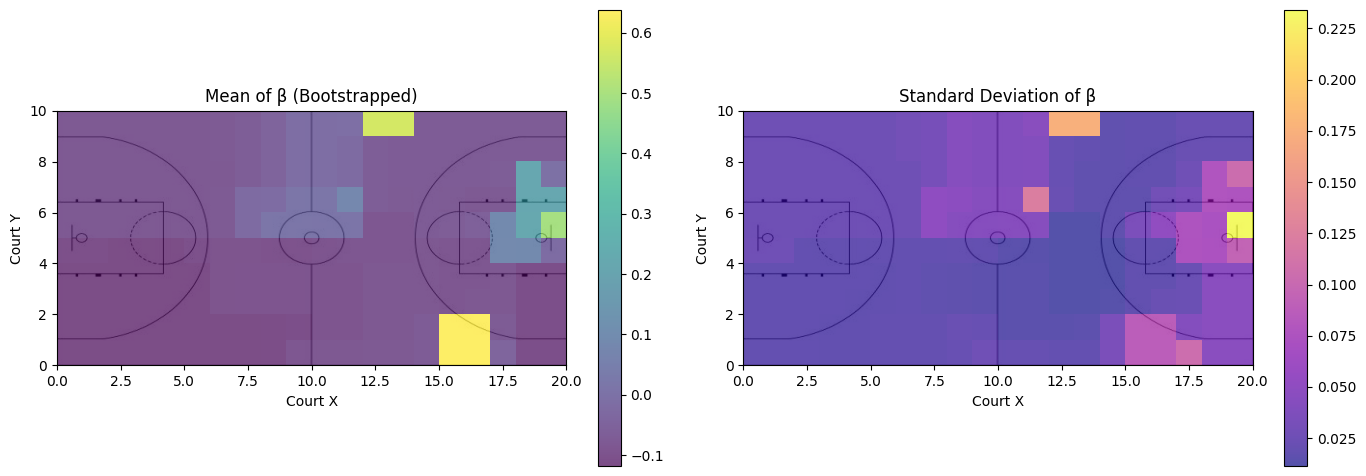

Simulating null responses...
Accepted 100 / 500 simulations
Accepted 200 / 500 simulations
Accepted 300 / 500 simulations
Accepted 400 / 500 simulations
Accepted 500 / 500 simulations
λ_qut (95th percentile null): 10.8102
λ_max (data): 23.6765


Computing λ_max for bootstraps: 100%|██████████| 100/100 [00:15<00:00,  6.46it/s]


λ_qut (95th percentile null): 10.8102
λ_max (observed): 23.6765
95% CI for λ_max (bootstrap): [17.2726, 26.4158]
Empirical p-value (λ_max > λ_qut): 0.0000


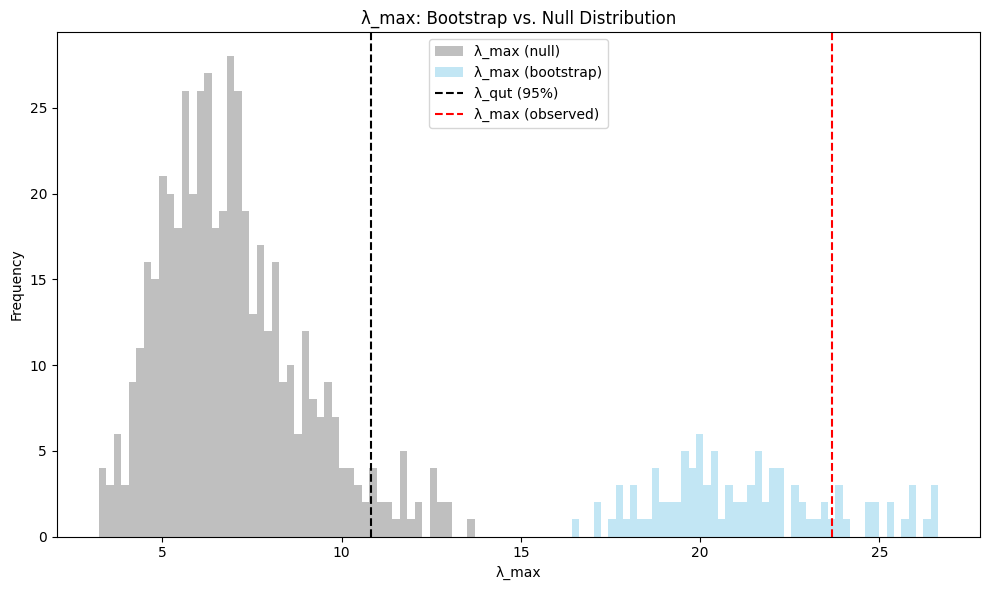

Bootstraps @ fixed λ=6: 100%|██████████| 100/100 [01:14<00:00,  1.35it/s]


Plotting pointwise percentile maps at fixed λ = 6


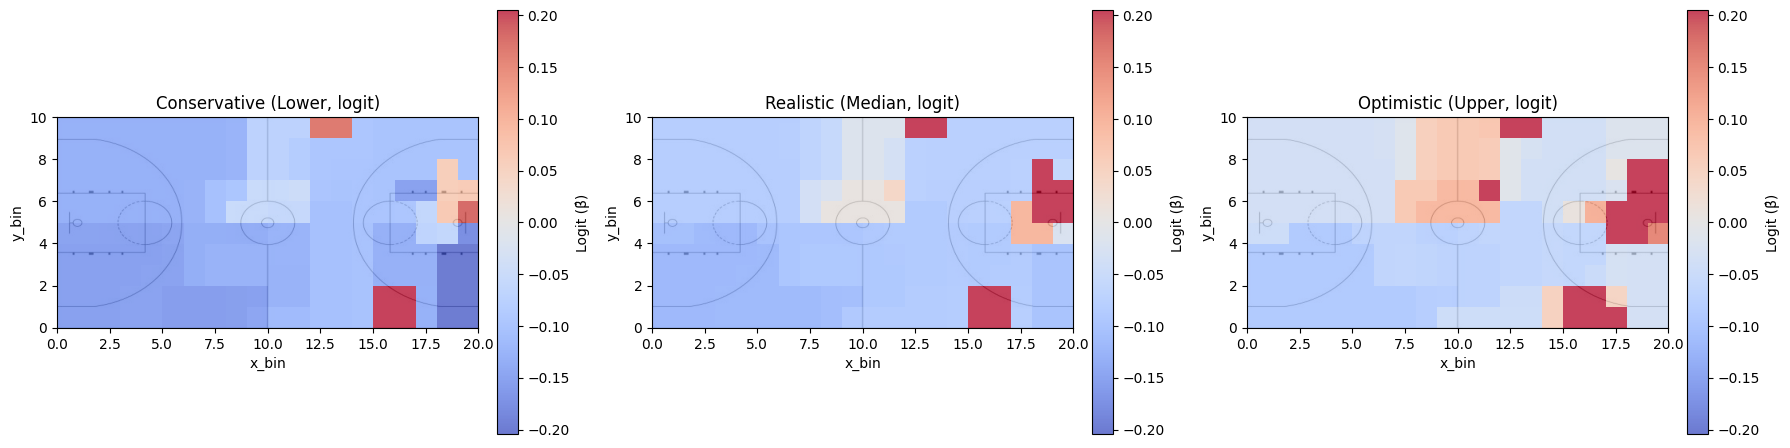


=== Processing Period 2 @ fixed λ=6 ===


Solving TV-Logistic: 100%|██████████| 100/100 [01:12<00:00,  1.37it/s]


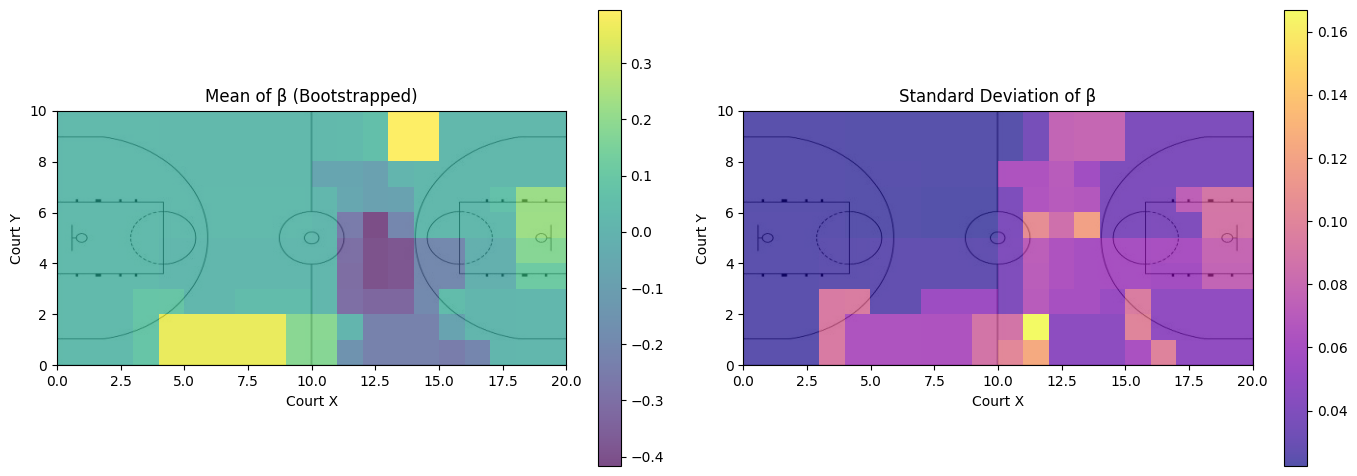

Simulating null responses...
Accepted 100 / 500 simulations
Accepted 200 / 500 simulations
Accepted 300 / 500 simulations
Accepted 400 / 500 simulations
Accepted 500 / 500 simulations
λ_qut (95th percentile null): 10.1346
λ_max (data): 32.9535


Computing λ_max for bootstraps: 100%|██████████| 100/100 [00:15<00:00,  6.37it/s]


λ_qut (95th percentile null): 10.1346
λ_max (observed): 32.9535
95% CI for λ_max (bootstrap): [24.5198, 34.6707]
Empirical p-value (λ_max > λ_qut): 0.0000


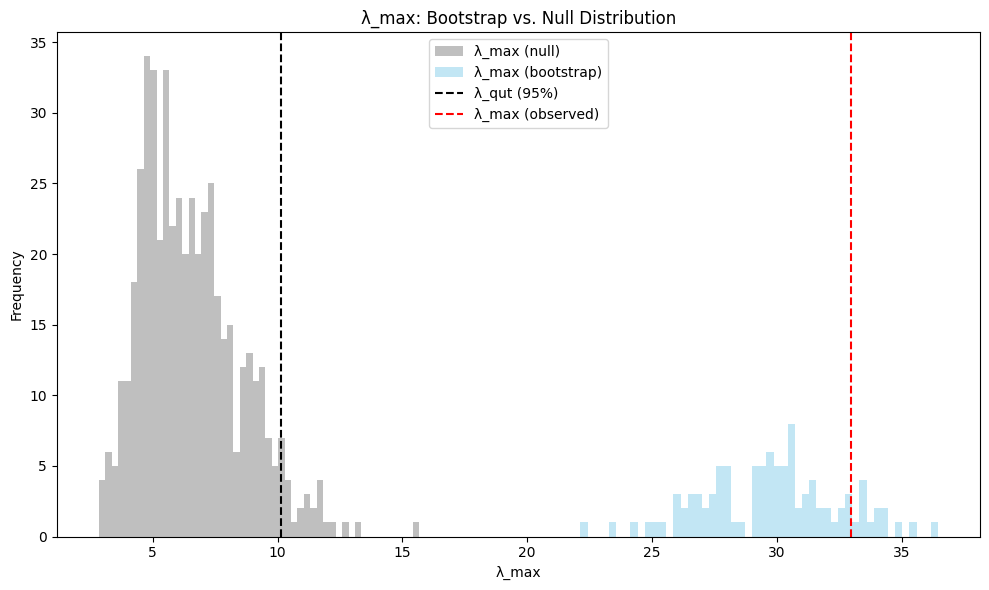

Bootstraps @ fixed λ=6: 100%|██████████| 100/100 [01:13<00:00,  1.36it/s]


Plotting pointwise percentile maps at fixed λ = 6


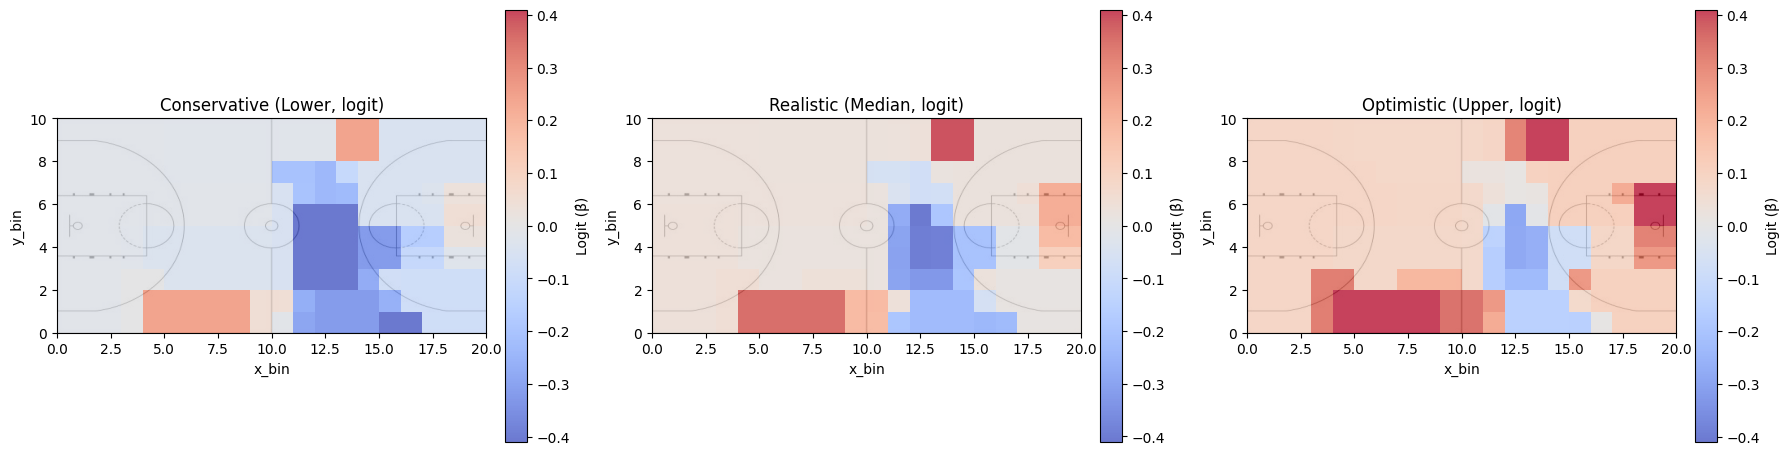


=== Processing Period 3 @ fixed λ=6 ===


Solving TV-Logistic: 100%|██████████| 100/100 [01:12<00:00,  1.37it/s]


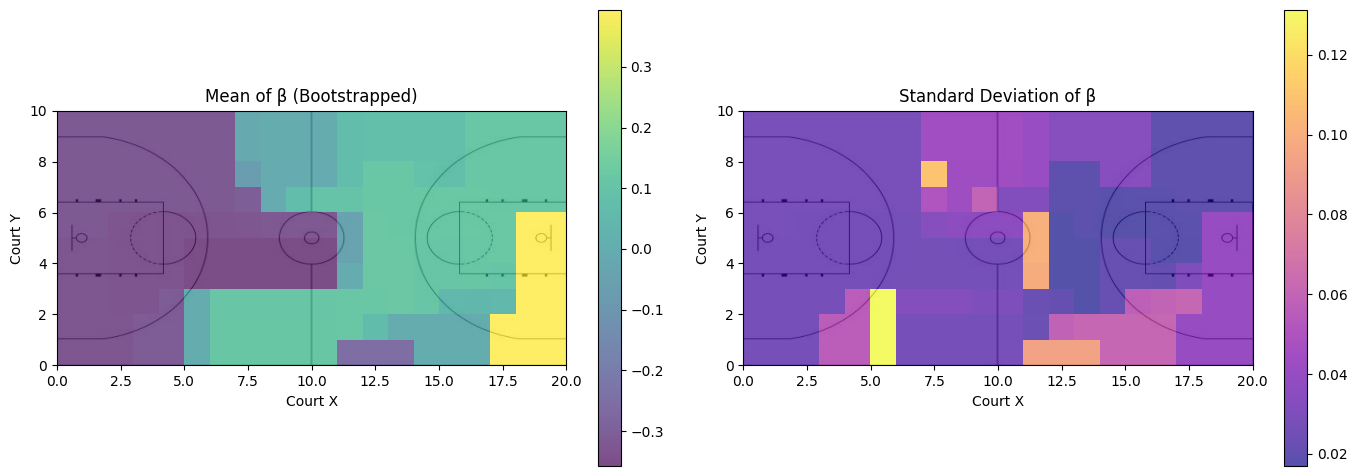

Simulating null responses...
Accepted 100 / 500 simulations
Accepted 200 / 500 simulations
Accepted 300 / 500 simulations
Accepted 400 / 500 simulations
Accepted 500 / 500 simulations
λ_qut (95th percentile null): 10.5735
λ_max (data): 44.4279


Computing λ_max for bootstraps: 100%|██████████| 100/100 [00:15<00:00,  6.50it/s]


λ_qut (95th percentile null): 10.5735
λ_max (observed): 44.4279
95% CI for λ_max (bootstrap): [36.9478, 49.1469]
Empirical p-value (λ_max > λ_qut): 0.0000


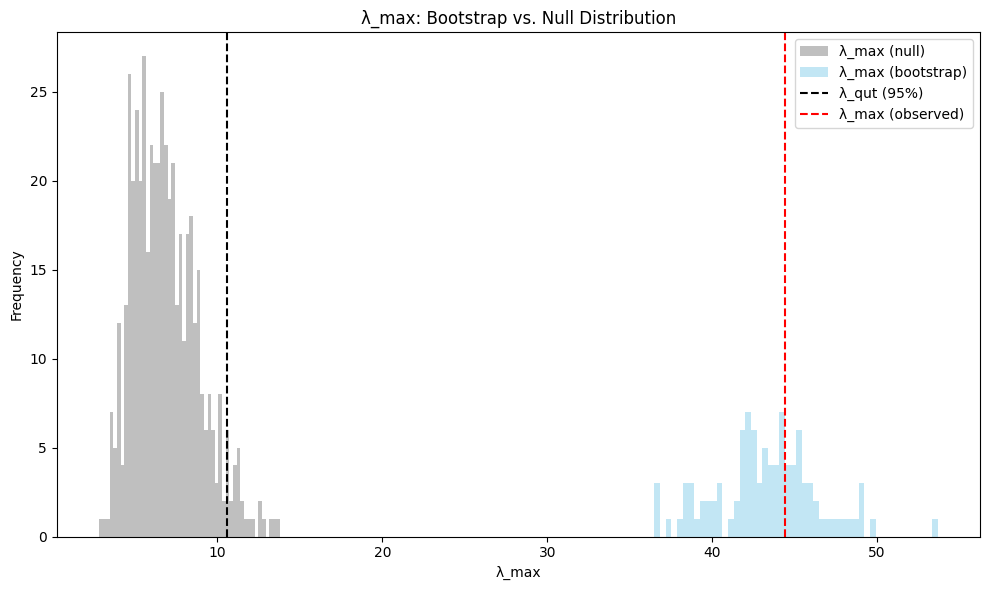

Bootstraps @ fixed λ=6: 100%|██████████| 100/100 [01:14<00:00,  1.35it/s]


Plotting pointwise percentile maps at fixed λ = 6


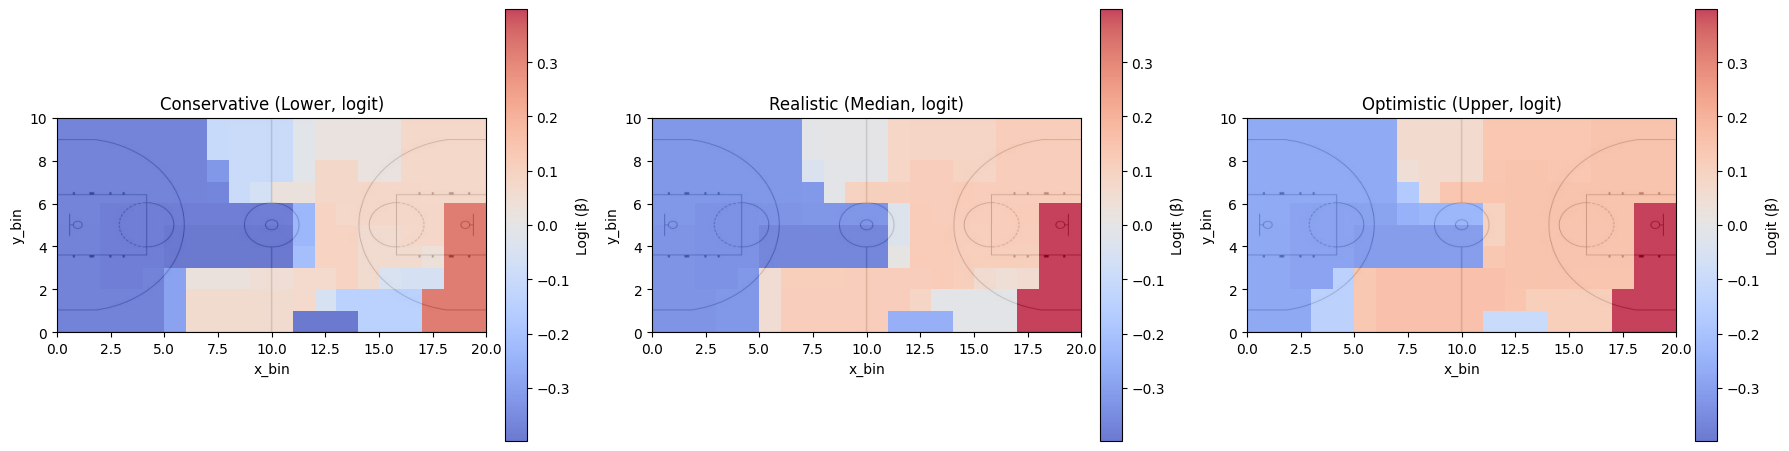


=== Processing Period 4 @ fixed λ=6 ===


Solving TV-Logistic: 100%|██████████| 100/100 [01:14<00:00,  1.34it/s]


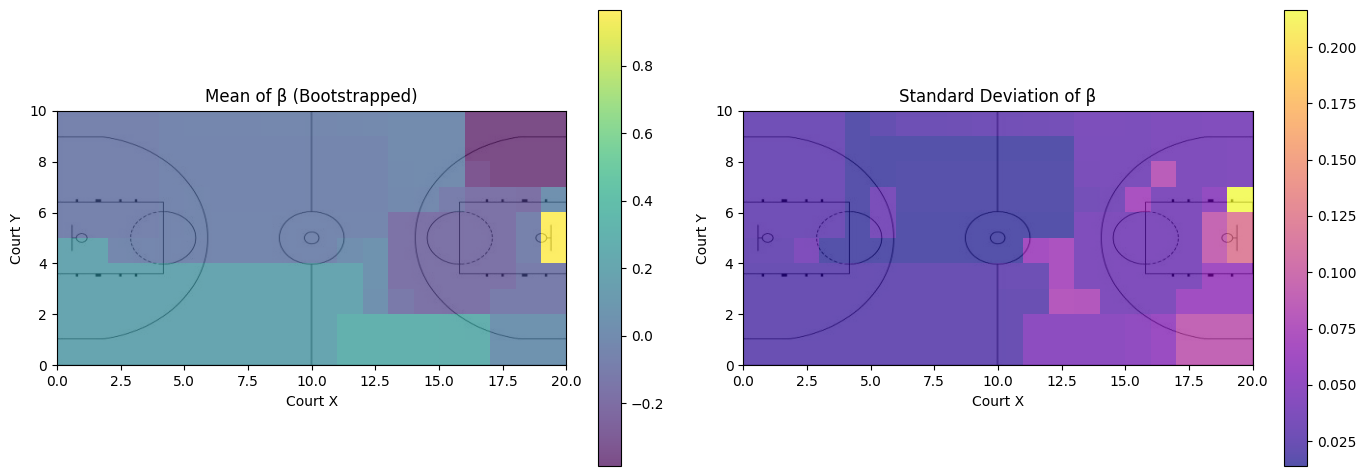

Simulating null responses...
Accepted 100 / 500 simulations
Accepted 200 / 500 simulations
Accepted 300 / 500 simulations
Accepted 400 / 500 simulations
Accepted 500 / 500 simulations
λ_qut (95th percentile null): 10.6399
λ_max (data): 39.7541


Computing λ_max for bootstraps: 100%|██████████| 100/100 [00:16<00:00,  6.24it/s]


λ_qut (95th percentile null): 10.6399
λ_max (observed): 39.7541
95% CI for λ_max (bootstrap): [33.4294, 43.0291]
Empirical p-value (λ_max > λ_qut): 0.0000


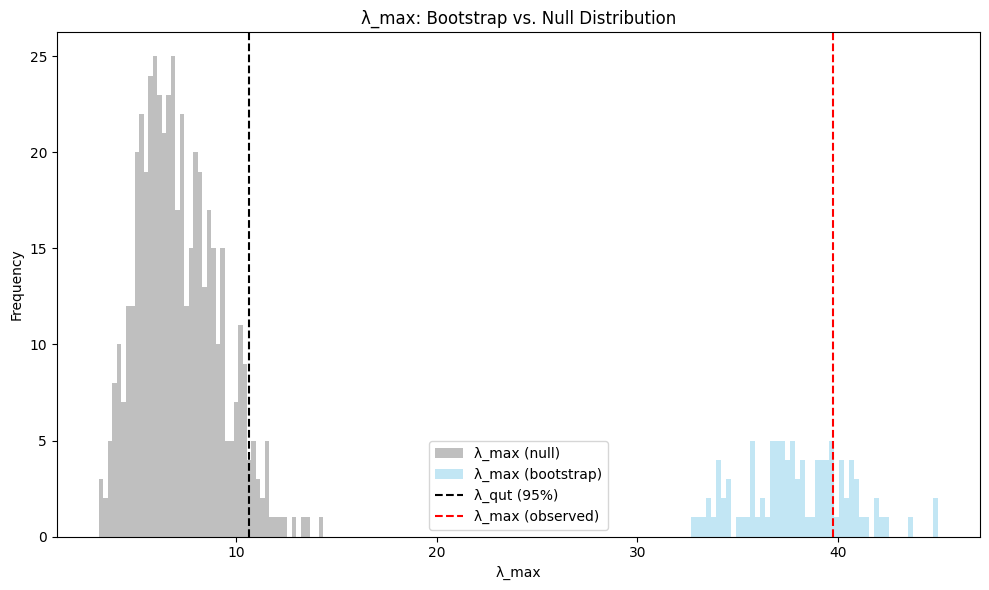

Bootstraps @ fixed λ=6: 100%|██████████| 100/100 [01:13<00:00,  1.36it/s]


Plotting pointwise percentile maps at fixed λ = 6


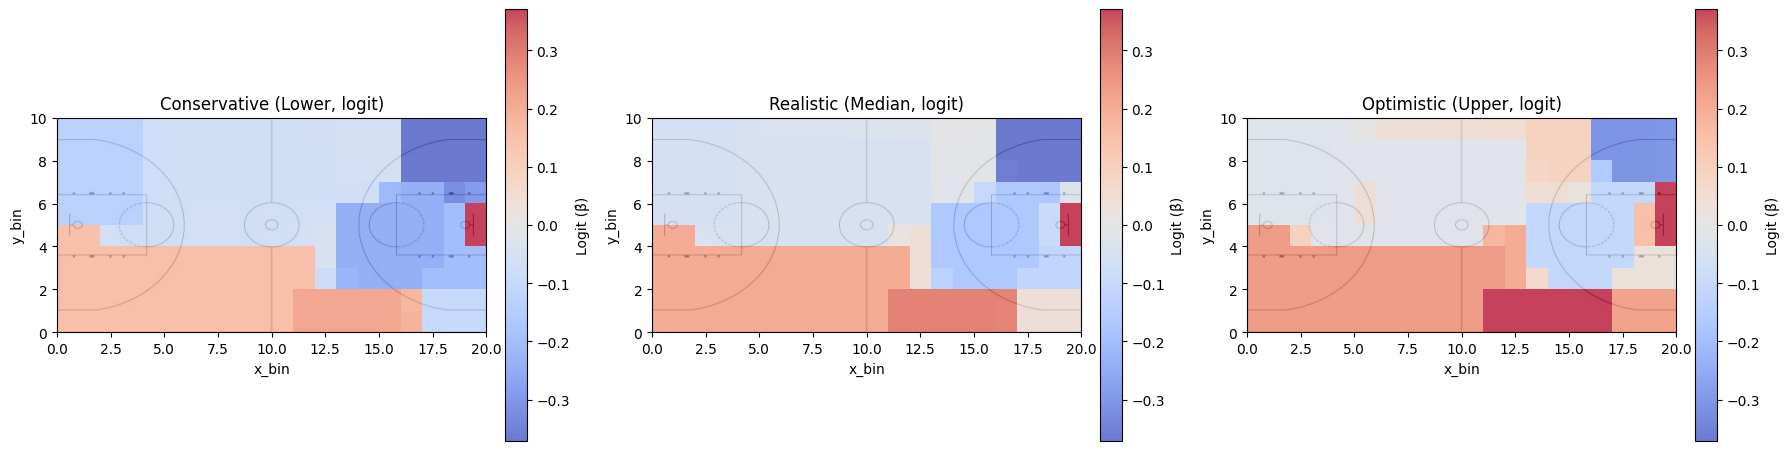

In [19]:
results = analyze_tv_logistic_per_period(df_original, 6)